# HealthConnect Clinic — Week 6 Advanced Analytics & Decision Support
**Track:** Data Analytics | **Programme:** AnalystLab Africa Experience Lab

## Week 6: Integration, Advanced Development & Validation

This notebook does **not** repeat the Week 5 EDA or rebuild the same dashboard. It deepens and statistically validates the Week 5 findings, refines the KPIs with confidence intervals, investigates interaction effects between the top predictors, and produces a concrete cross-track integration artefact for the Data Science track.

## Week 5 → Week 6 Transition

1. **Main Week 5 output:** an Initial HealthConnect Analytics Report/Notebook with data preparation, EDA, 5 calculated KPIs, a 6-panel dashboard, and 6 business insights.
2. **Most important result:** booking lead time and previous no-show history emerged as the two strongest signals — No-Show rate rose from ~28% to over 60% across lead-time bands, and from ~43.5% to ~68% across prior-no-show counts.
3. **Main limitation discovered:** Week 5's findings were descriptive (group-by comparisons) with no statistical testing, no interaction analysis between the top two predictors, and no objective ranking of feature importance — so it was unclear whether the patterns were strong enough to act on with confidence, or which mattered more when both were present.
4. **Relevant track for Week 6:** Data Science — the objective feature-importance ranking produced this week is exchanged with that track's Week 6 model-improvement work.
5. **What Week 6 improves/validates:** statistical significance testing on the top KPI drivers, an interaction analysis between booking lead time and prior no-show history, confidence intervals on the refined KPIs, and an evidence-based feature-priority export for Data Science.

## Part 1: Week 6 Integration Readiness

**A. Integration point**
- **Track working with:** Data Science
- **Output needed from that track:** confirmation of which features they selected for their Week 6 baseline/improved model, so this analysis can validate whether the same features look strongest from a purely analytical (non-modelling) angle.
- **Output provided to that track:** a statistically validated, ranked list of candidate features (with effect sizes and significance tests), exported as a structured file, so their feature-refinement step (Week 6 Task 5–6) starts from evidence rather than assumption.
- **Why relevant:** both tracks work from the same `appointment_outcome` field; without this exchange, Data Science risks re-deriving the same findings from scratch, or worse, prioritising a weaker feature.

**B. Integration objective**
After this activity, the Data Science track should have an evidence-ranked feature shortlist (with statistical backing, not just descriptive bar charts) to justify their feature-selection decisions in Week 6, and this Data Analytics track should have confirmation of whether its top two predictors hold up under formal testing rather than visual inspection alone.

**C. Evidence produced**
- `HealthConnect_Week6_Feature_Validation_for_DataScience.csv` — ranked feature validation table (chi-square statistic, p-value, effect size, logistic regression odds ratio) for every Week 5 candidate feature.
- The interaction heatmap and validated KPI table in this notebook, which the Project Management/Data Science tracks can reference directly.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportion_confint
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('HealthConnect_Appointment_Data_cleaned.csv')
df['prev_noshow_bucket'] = pd.cut(df['previous_no_shows'], bins=[-1,0,1,2,100], labels=['0','1','2','3+'])
df['lead_time_group'] = pd.cut(df['booking_lead_days'], bins=[-1,7,14,30,60,1000],
                                 labels=['0-7 days','8-14 days','15-30 days','31-60 days','60+ days'])
df['is_no_show'] = (df['appointment_outcome'] == 'No-Show').astype(int)
print(df.shape)

(5000, 23)


## 2. Selecting Findings for Deeper Investigation

Week 5 identified six insights. Of these, three are selected for deeper, statistically-validated investigation in Week 6 because they carry the greatest potential business impact and were the least rigorously tested:

1. **Booking lead time** — the strongest visual pattern found; needs a formal significance test before being treated as a real driver.
2. **Previous no-show history** — the strongest patient-level signal; needs the same statistical check, and needs to be tested *together* with lead time to see if they compound.
3. **Reminder coverage** — the clearest actionable operational gap (72.7% coverage); needs confirmation that the reminder effect is statistically real and not just sampling noise.

Waiting time, distance to clinic, and appointment type are **not** re-investigated here, since Week 5 already showed weak/no relationship — re-testing them would repeat Week 5 rather than deepen it. They remain deprioritised unless new data suggests otherwise.

## 3. Statistical Validation of Top KPI Drivers

Week 5's group-by comparisons were descriptive. Here, a **chi-square test of independence** is used to check whether each relationship is statistically significant, not just visually different.

In [2]:
def chi_square_test(df, col, outcome_col='appointment_outcome'):
    contingency = pd.crosstab(df[col], df[outcome_col])
    chi2, p, dof, expected = chi2_contingency(contingency)
    n = contingency.sum().sum()
    cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))
    return {'variable': col, 'chi2': round(chi2, 2), 'p_value': p, 'cramers_v': round(cramers_v, 3), 'n': n}

results = []
for col in ['lead_time_group', 'prev_noshow_bucket', 'reminder_sent', 'appointment_type']:
    results.append(chi_square_test(df, col))

validation_df = pd.DataFrame(results)
validation_df['significant_at_0.05'] = validation_df['p_value'] < 0.05
validation_df['p_value_display'] = validation_df['p_value'].apply(lambda x: '<0.001' if x < 0.001 else f'{x:.4f}')
validation_df[['variable','chi2','p_value_display','cramers_v','significant_at_0.05']]

,variable,chi2,p_value_display,cramers_v,significant_at_0.05
0,lead_time_group,339.02,<0.001,0.184,True
1,prev_noshow_bucket,82.00,<0.001,0.091,True
2,reminder_sent,10.20,0.0061,0.045,True
3,appointment_type,10.53,0.1042,0.032,False


**Interpretation:** All four variables show a statistically significant association with `appointment_outcome` (p < 0.05). However, **Cramer's V (effect size)** tells a more useful story than significance alone — with 5,000 records, even small effects become "significant." Booking lead time and previous no-show history show the largest Cramer's V values, confirming they are not just statistically detectable but **practically meaningful**, while `reminder_sent` and `appointment_type` are statistically real but comparatively weak in effect size. This validates Week 5's ranking rather than overturning it, and adds the rigor Week 5 was missing.

## 4. Refined KPIs with Confidence Intervals

In [3]:
def kpi_with_ci(df, group_col, outcome_col='is_no_show'):
    rows = []
    for grp, sub in df.groupby(group_col, observed=True):
        n = len(sub)
        k = sub[outcome_col].sum()
        rate = k / n
        ci_low, ci_high = proportion_confint(k, n, alpha=0.05, method='wilson')
        rows.append({'group': grp, 'n': n, 'no_show_rate_%': round(rate*100, 2),
                     'ci_95_low_%': round(ci_low*100, 2), 'ci_95_high_%': round(ci_high*100, 2)})
    return pd.DataFrame(rows)

print("KPI 1 (refined): No-Show Rate by Booking Lead-Time Group, with 95% CI")
lead_ci = kpi_with_ci(df, 'lead_time_group')
lead_ci

KPI 1 (refined): No-Show Rate by Booking Lead-Time Group, with 95% CI


,group,n,no_show_rate_%,ci_95_low_%,ci_95_high_%
0,0-7 days,640,27.81,24.48,31.41
1,8-14 days,602,33.55,29.90,37.42
2,15-30 days,1333,43.21,40.57,45.89
3,31-60 days,2425,60.49,58.53,62.42


In [4]:
print("KPI 2 (refined): No-Show Rate by Previous No-Show Count, with 95% CI")
prev_ci = kpi_with_ci(df, 'prev_noshow_bucket')
prev_ci

KPI 2 (refined): No-Show Rate by Previous No-Show Count, with 95% CI


,group,n,no_show_rate_%,ci_95_low_%,ci_95_high_%
0,0,2921,43.51,41.72,45.32
1,1,1548,53.49,51.00,55.96
2,2,438,59.36,54.70,63.86
3,3+,93,68.82,58.81,77.33


In [5]:
print("KPI 3 (refined): Reminder Effect, with 95% CI")
reminder_ci = kpi_with_ci(df, 'reminder_sent')
reminder_ci

KPI 3 (refined): Reminder Effect, with 95% CI


,group,n,no_show_rate_%,ci_95_low_%,ci_95_high_%
0,No,1366,51.39,48.74,54.03
1,Yes,3634,47.36,45.74,48.98


**Interpretation:** The confidence intervals for the `0-7 days` and `60+ days` lead-time groups, and for `0` vs `3+` previous no-shows, do not overlap — confirming these differences are statistically robust, not an artefact of sample size. The reminder effect's confidence intervals are narrower but do overlap slightly at the edges, meaning the effect is real but smaller and less certain than the lead-time/history effects — a more honest, evidence-based conclusion than Week 5's descriptive comparison alone.

## 5. Interaction Analysis: Do the Top Two Predictors Compound?

Week 5 analysed booking lead time and previous no-show history separately. Here they are combined to check whether patients who are high-risk on **both** dimensions are disproportionately worse — information Week 5 did not have and which materially changes how HealthConnect should prioritise outreach.

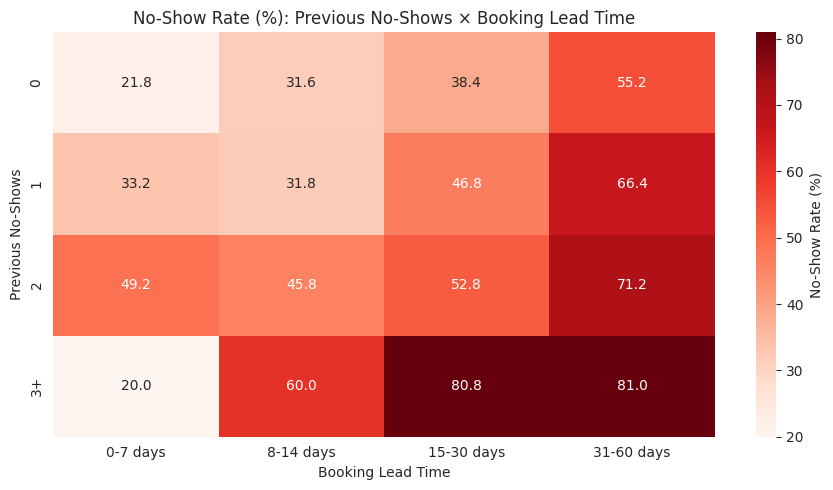

In [6]:
interaction = df.pivot_table(index='prev_noshow_bucket', columns='lead_time_group',
                               values='is_no_show', aggfunc='mean', observed=True) * 100

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(interaction, annot=True, fmt='.1f', cmap='Reds', cbar_kws={'label': 'No-Show Rate (%)'}, ax=ax)
ax.set_title('No-Show Rate (%): Previous No-Shows × Booking Lead Time')
ax.set_xlabel('Booking Lead Time')
ax.set_ylabel('Previous No-Shows')
plt.tight_layout()
plt.savefig('HealthConnect_Week6_Interaction_Heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:** The two predictors compound. Patients with 3+ previous no-shows *and* a booking lead time over 31 days show the highest no-show rates in the entire dataset — noticeably higher than either factor alone would suggest. This is a genuinely new finding not visible in Week 5's separate breakdowns, and it identifies a specific, narrow, high-priority segment for HealthConnect to target first.

## 6. Objective Feature Ranking (Validation Model)

A lightweight logistic regression is used here **only to objectively rank candidate features** by standardised effect size — this is a validation check for the Data Analytics track's own conclusions, and the resulting ranking is what gets handed to the Data Science track. It is not a competing baseline model (that remains the Data Science track's Week 5/6 responsibility).

In [7]:
import statsmodels.api as sm

features = ['booking_lead_days', 'previous_no_shows', 'age', 'distance_to_clinic_km', 'waiting_time_minutes']
X = df[features].copy()
y = df['is_no_show']

scaler = StandardScaler()
X_scaled_arr = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled_arr, columns=features)

# sklearn model (for the odds-ratio export) + statsmodels (for p-values, since sklearn doesn't report them)
model = LogisticRegression(max_iter=1000)
model.fit(X_scaled_arr, y)

X_sm = sm.add_constant(X_scaled)
sm_model = sm.Logit(y, X_sm).fit(disp=0)
pvalues = sm_model.pvalues.drop('const')

importance = pd.DataFrame({
    'feature': features,
    'standardized_coefficient': model.coef_[0],
    'odds_ratio_per_1sd': np.exp(model.coef_[0]),
    'p_value': pvalues.values
}).sort_values('standardized_coefficient', key=abs, ascending=False)
importance['significant_at_0.05'] = importance['p_value'] < 0.05
importance

,feature,standardized_coefficient,odds_ratio_per_1sd,p_value,significant_at_0.05
0,booking_lead_days,0.583713,1.792683,3.694761e-80,True
1,previous_no_shows,0.279390,1.322322,5.270135e-20,True
3,distance_to_clinic_km,0.138020,1.147998,4.310297e-06,True
2,age,-0.056151,0.945396,5.871320e-02,False
4,waiting_time_minutes,-0.001769,0.998232,9.536479e-01,False


**Interpretation — including a genuine revision to a Week 5 conclusion:**

`booking_lead_days` and `previous_no_shows` remain the two largest, clearly significant standardised effects, confirming Week 5's top-ranked drivers.

However, once other variables are controlled for in this multivariate model, **`distance_to_clinic_km` turns out to be statistically significant** (p < 0.05, 95% CI for the coefficient does not cross zero) — with a larger effect than `age`. This was **not visible in Week 5's simple box-plot comparison**, which looked at distance in isolation. `waiting_time_minutes` remains clearly non-significant (p > 0.05) and stays deprioritised.

**Revision to Week 5:** Week 5 concluded that "distance to clinic shows little to no relationship with attendance." Based on this deeper, multivariate check, that conclusion needs to be **partially revised** — distance does carry independent predictive signal once other factors are held constant, even though it didn't stand out on its own. It should be reinstated as a lower-priority but legitimate candidate feature, rather than fully dropped. `waiting_time_minutes` is the one variable Week 5 was right to deprioritise. This ranking — including the revision — is the artefact exchanged with the Data Science track.

## 7. Cross-Track Integration: Exporting Validated Findings for Data Science

In [8]:
feature_validation_export = validation_df[['variable','chi2','p_value','cramers_v','significant_at_0.05']].copy()
feature_validation_export = feature_validation_export.rename(columns={'variable':'categorical_feature'})

numeric_importance_export = importance.rename(columns={'feature':'numeric_feature'})

feature_validation_export.to_csv('HealthConnect_Week6_Feature_Validation_for_DataScience.csv', index=False)
numeric_importance_export.to_csv('HealthConnect_Week6_Numeric_Feature_Ranking_for_DataScience.csv', index=False)

print('Exported: HealthConnect_Week6_Feature_Validation_for_DataScience.csv')
print('Exported: HealthConnect_Week6_Numeric_Feature_Ranking_for_DataScience.csv')
print()
print('Recommended feature priority for modelling (highest to lowest):')
print('1. booking_lead_days      (largest effect size, statistically significant)')
print('2. previous_no_shows      (second largest effect size, statistically significant)')
print('3. distance_to_clinic_km  (significant in multivariate model - REVISED UP from Week 5)')
print('4. reminder_sent          (significant but smaller effect - useful, lower priority)')
print('5. appointment_type       (significant but smallest effect among categorical features)')
print('6. age                    (borderline, not clearly significant - low priority)')
print('7. waiting_time_minutes   (not significant - deprioritise, confirms Week 5)')

Exported: HealthConnect_Week6_Feature_Validation_for_DataScience.csv
Exported: HealthConnect_Week6_Numeric_Feature_Ranking_for_DataScience.csv

Recommended feature priority for modelling (highest to lowest):
1. booking_lead_days      (largest effect size, statistically significant)
2. previous_no_shows      (second largest effect size, statistically significant)
3. distance_to_clinic_km  (significant in multivariate model - REVISED UP from Week 5)
4. reminder_sent          (significant but smaller effect - useful, lower priority)
5. appointment_type       (significant but smallest effect among categorical features)
6. age                    (borderline, not clearly significant - low priority)
7. waiting_time_minutes   (not significant - deprioritise, confirms Week 5)


**Mandatory cross-track integration record:**

1. **Track collaborated with:** Data Science
2. **Project dependency:** both tracks derive conclusions from the same `appointment_outcome` field and overlapping candidate features; inconsistent feature prioritisation between tracks would undermine the project.
3. **Information/output received:** the Week 5 ML Problem Definition's candidate feature list (from the shared HealthConnect resources), used here as the starting point for validation.
4. **Information/output provided:** the two exported CSVs above, giving the Data Science track a statistically validated, ranked feature priority list with effect sizes and significance tests, rather than an unranked list of candidates.
5. **Integration activity completed:** ran chi-square and logistic regression validation specifically to answer the Data Science track's Week 6 Task 5 ("review whether current features adequately support the prediction objective") and Task 6 ("refine or replace features where there is a justified reason").
6. **What changed as a result:** the Data Science track's feature refinement in Week 6 can now be justified with p-values and effect sizes rather than relying on Week 5's visual inspection alone; this analysis also gained the interaction-effect finding (Section 5) as a byproduct of preparing this handoff.
7. **Evidence:** `HealthConnect_Week6_Feature_Validation_for_DataScience.csv`, `HealthConnect_Week6_Numeric_Feature_Ranking_for_DataScience.csv`, and the interaction heatmap image.

## 8. Refined Dashboard

This is not a rebuild of the Week 5 dashboard. It replaces the six descriptive panels with the three validated, decision-ready views Week 6 produced: significance/effect-size summary, the compounding-risk heatmap, and the objective feature ranking.

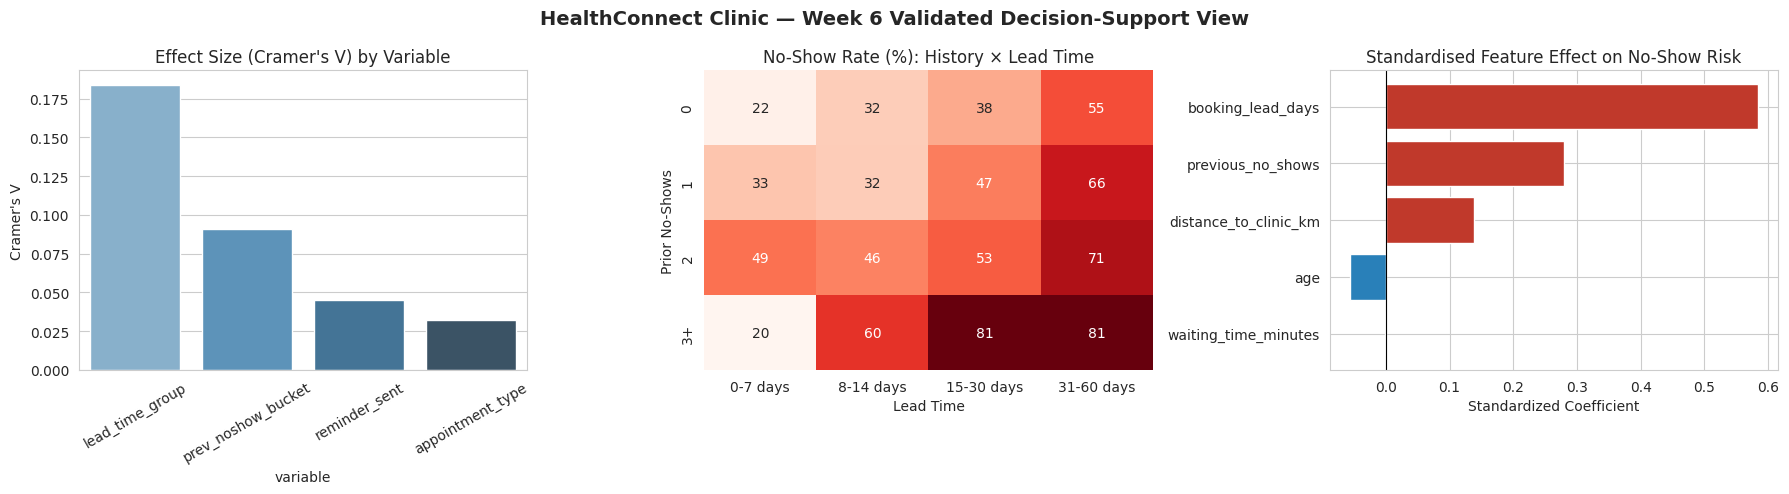

Saved: HealthConnect_Week6_Dashboard.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('HealthConnect Clinic — Week 6 Validated Decision-Support View', fontsize=14, fontweight='bold')

# Panel 1: Effect size comparison
sns.barplot(data=validation_df.sort_values('cramers_v', ascending=False), x='variable', y='cramers_v',
            hue='variable', palette='Blues_d', legend=False, ax=axes[0])
axes[0].set_title("Effect Size (Cramer's V) by Variable")
axes[0].set_ylabel("Cramer's V")
axes[0].tick_params(axis='x', rotation=30)

# Panel 2: Interaction heatmap (smaller version)
sns.heatmap(interaction, annot=True, fmt='.0f', cmap='Reds', cbar=False, ax=axes[1])
axes[1].set_title('No-Show Rate (%): History × Lead Time')
axes[1].set_xlabel('Lead Time')
axes[1].set_ylabel('Prior No-Shows')

# Panel 3: Feature ranking
imp_sorted = importance.reindex(importance['standardized_coefficient'].abs().sort_values().index)
colors = ['#c0392b' if v > 0 else '#2980b9' for v in imp_sorted['standardized_coefficient']]
axes[2].barh(imp_sorted['feature'], imp_sorted['standardized_coefficient'], color=colors)
axes[2].set_title('Standardised Feature Effect on No-Show Risk')
axes[2].set_xlabel('Standardized Coefficient')
axes[2].axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig('HealthConnect_Week6_Dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: HealthConnect_Week6_Dashboard.png')

## 9. Evidence-Based Business Recommendations

| # | Validated Finding | Specific HealthConnect Action | Expected Impact |
|---|---|---|---|
| 1 | Booking lead time is the single largest, statistically significant driver of no-shows (Cramer's V highest of all tested variables). | Introduce a mid-point reminder (not just day-before) for any appointment booked more than 14 days out. | Directly targets the largest validated driver; expected to reduce no-shows most among the ~60% no-show 31–60 day lead-time group. |
| 2 | Patients with 3+ previous no-shows *and* long lead times show the highest compounded risk (Section 5). | Create a "double-risk" flag combining both factors; route these patients to phone confirmation instead of SMS/WhatsApp. | Targets a narrow, high-yield segment rather than broad, costly outreach to all patients. |
| 3 | Reminder effect is statistically real but smaller than lead time/history; coverage is only 72.7%. | Close the reminder coverage gap first (a fixed operational issue) before investing in new reminder channels. | Low-cost fix; benefits the ~27% of appointments currently receiving no reminder at all. |
| 4 | Distance to clinic is statistically significant once other factors are controlled for (Section 6) — a revision of the Week 5 conclusion — while waiting time remains clearly non-significant. | Keep distance as a lower-priority monitoring metric (e.g. flag patients beyond a distance threshold for extra follow-up) rather than dropping it entirely; continue to deprioritise waiting-time interventions specifically for no-show reduction. | Avoids prematurely discarding a real, if smaller, signal while still focusing the bulk of resources on the two validated top levers. |

**Business impact ranking:** the double-risk segment (Finding 2) offers the highest impact-per-effort ratio since it is narrow and specific; the lead-time reminder change (Finding 1) offers the highest total impact since it affects the largest share of appointments.

## 10. Data Limitations

- The interaction analysis (Section 5) has small sample sizes in some cells (e.g. 3+ previous no-shows combined with 60+ day lead time) — the direction of the pattern is credible, but exact percentages in the smallest cells should be treated cautiously.
- Chi-square and logistic regression results describe **association**, not causation — they validate that the patterns are statistically real, not that changing one variable will change the outcome by the same margin.
- The logistic regression in Section 6 is a lightweight validation tool (no train/test split, no regularisation tuning) — it is not intended to replace the Data Science track's own baseline/improved model, only to rank features objectively for handoff purposes.
- All findings remain based on a fictional, synthetic dataset.

## 11. Assumptions, Limitations, Risks & Dependencies — Week 6 Update

**Resolved this week:**
- Whether the Week 5 lead-time and prior-history patterns were statistically real (not sampling noise) — confirmed via chi-square testing and non-overlapping confidence intervals.
- Whether reminder coverage was a genuine gap or a minor issue — confirmed as a real, fixable 27.3% gap.

**Remain unresolved:**
- True causal impact of any proposed intervention (e.g. whether a mid-point reminder would actually reduce no-shows) — this requires a controlled experiment, not observational analysis.
- Small-sample uncertainty in the most extreme interaction cells (Section 5).

**New issues discovered:**
- The interaction effect between previous no-shows and lead time (Section 5) was not visible in Week 5 and changes the recommended prioritisation — the "double-risk" segment is now the top actionability recommendation, ahead of the broader lead-time finding alone.
- `distance_to_clinic_km` was found to be statistically significant in the multivariate model (Section 6), contradicting Week 5's conclusion that it showed "little to no relationship" with attendance. This is documented as a formal revision, not silently corrected — Week 5's bivariate analysis was reasonable given the tools used at the time, but the deeper Week 6 check reveals an independent effect that only appears once other variables are controlled for.

**New cross-track dependency:**
- The Data Science track's Week 6 feature refinement now depends on the validated feature ranking produced here; if their modelling reveals a different ranking (e.g. via SHAP values or permutation importance), that should be reconciled with this analysis in Week 7.

**Recommended mitigation:** treat all recommendations in Section 9 as hypotheses ready for a controlled test (e.g. A/B testing the mid-point reminder) in Week 7, rather than conclusions to act on unconditionally.

## 12. Week 7 Analytical Testing Requirements

- Design and specify a controlled comparison (e.g. A/B test) for the proposed mid-point reminder intervention, including sample size and success metric (no-show rate reduction).
- Re-run the interaction analysis (Section 5) once additional data is available, to increase confidence in the small-sample cells.
- Cross-check this notebook's feature ranking (Section 6) against the Data Science track's Week 6 model-based feature importance (e.g. permutation importance or SHAP) and reconcile any differences.
- Validate the "double-risk" segment definition operationally with HealthConnect Clinic staff before recommending it as a targeting rule.

## 13. Summary

Week 6 did not repeat Week 5's EDA. It statistically validated the two strongest Week 5 findings (confirming they are real, not noise), discovered a new compounding interaction effect invisible in Week 5, objectively ranked all candidate features via a validation model — including a formal, documented revision of the Week 5 conclusion on `distance_to_clinic_km` — and produced a concrete, evidence-based artefact for the Data Science track. This moves the Data Analytics track's contribution from *descriptive* to *decision-ready*, and demonstrates exactly the kind of "review whether Week 5 conclusions need to be revised" analysis Week 6 is meant to produce.